In [3]:
import seaborn as sns
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

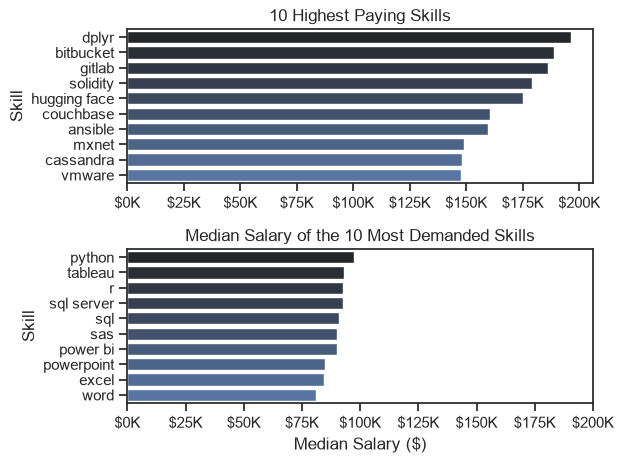

In [ ]:
df_DA = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()
df_DA = df_DA.dropna(subset = ['salary_year_avg'])
df_DA = df_DA.explode('job_skills')
df_DA[['salary_year_avg', 'job_skills']]

grouped_m= df_DA.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by = 'median', ascending = False).head(10)
grouped_c= df_DA.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by = 'count', ascending = False).head(10)


grouped_m = grouped_m['median'].sort_values(ascending = False)
grouped_c = grouped_c['median'].sort_values(ascending = False)

merged = grouped_c.to_frame('count_median').merge(
    grouped_m.to_frame('pay_median'),
    left_index=True,
    right_index=True,
    how='outer'
)

fig, ax = plt.subplots(2, 1)
sns.set_theme(style = 'ticks')

sns.barplot(x=grouped_m.values, y=grouped_m.index, ax=ax[0], hue= grouped_m.index,  palette='dark:b', legend=False)

ax[0].set_title('10 Highest Paying Skills')

ax[0].set_ylabel('Skill')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


sns.barplot(x= grouped_c.values, y=grouped_c.index, ax=ax[1], hue=grouped_c.index, palette='dark:b', legend=False)

ax[1].set_title('Median Salary of the 10 Most Demanded Skills')
ax[1].set_xlabel('Median Salary ($)')
ax[1].set_ylabel('Skill')
ax[1].set_xlim(0, 200000)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()

In [9]:
merged = grouped_c.to_frame('count_median').merge(
    grouped_m.to_frame('pay_median'),
    left_index=True,
    right_index=True,
    how='outer'
)
merged['median'] = merged['pay_median'].combine_first(merged['count_median'])
merged

,count_median,pay_median,median
job_skills,,,
ansible,NaN,159640.0,159640.00
bitbucket,NaN,189000.0,189000.00
cassandra,NaN,148250.0,148250.00
couchbase,NaN,160515.0,160515.00
dplyr,NaN,196250.0,196250.00
excel,84392.00,NaN,84392.00
gitlab,NaN,186000.0,186000.00
hugging face,NaN,175000.0,175000.00
mxnet,NaN,149000.0,149000.00
